In [1]:
import pandas as pd

df = pd.read_csv('aice_day7_knn_practice.csv')

In [2]:
df.head()

,customer_id,age,monthly_fee,tenure_months,support_calls,data_usage_gb,gender,city,plan,contract_type,churn
0,C0001,59.0,77.1,8,3,23.1,M,Busan,Standard,One-year,0
1,C0002,20.0,80.1,6,1,24.1,M,Busan,Standard,One-year,0
2,C0003,47.0,47.8,38,1,39.9,M,Incheon,Basic,Month-to-month,1
3,C0004,25.0,61.9,23,1,29.0,M,Incheon,Standard,Two-year,0
4,C0005,54.0,73.5,19,2,11.0,F,Busan,Standard,Month-to-month,1


In [3]:
df.isnull().sum()

customer_id      0
age              7
monthly_fee      6
tenure_months    0
support_calls    0
data_usage_gb    0
gender           0
city             5
plan             0
contract_type    0
churn            0
dtype: int64

In [4]:
df.describe()

,age,monthly_fee,tenure_months,support_calls,data_usage_gb,churn
count,233.000000,234.000000,240.000000,240.000000,240.000000,240.000000
mean,45.841202,71.981624,30.137500,1.704167,22.056667,0.208333
std,15.311299,40.853098,16.923216,1.411246,9.085634,0.406965
min,19.000000,17.100000,1.000000,0.000000,1.000000,0.000000
25%,33.000000,44.900000,15.750000,0.000000,15.875000,0.000000
50%,47.000000,65.950000,30.500000,2.000000,21.850000,0.000000
75%,58.000000,85.525000,45.000000,3.000000,27.800000,0.000000
max,72.000000,420.000000,60.000000,6.000000,60.800000,1.000000


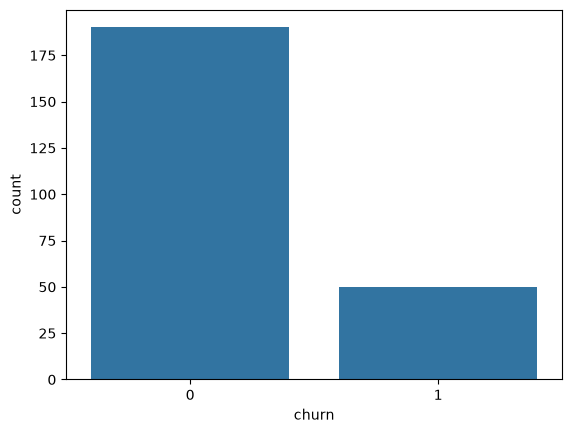

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='churn')
plt.show()
# 자료 불균형 의심

In [6]:
df['churn'].value_counts()

churn
0    190
1     50
Name: count, dtype: int64

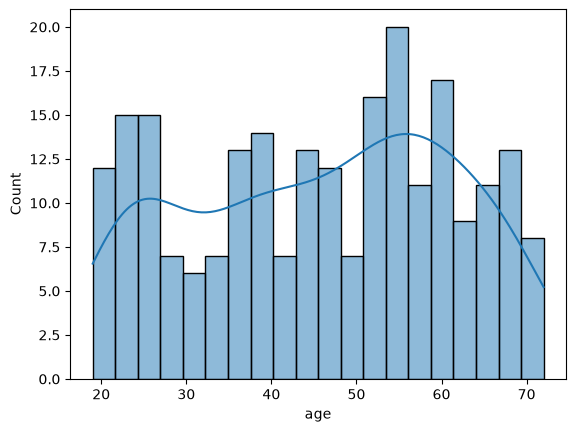

In [7]:
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.show()
# 전반적으로 고른 분포

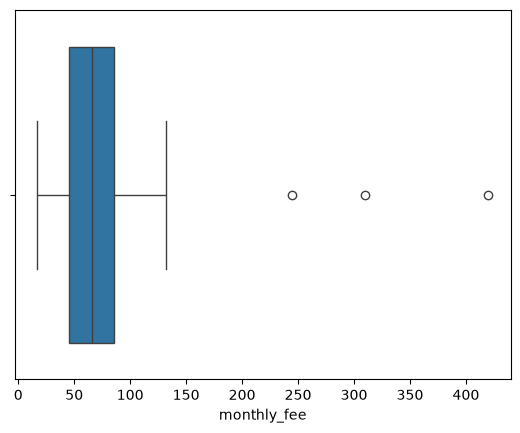

In [8]:
sns.boxplot(data=df, x='monthly_fee')
plt.show()
# 이상치 의심

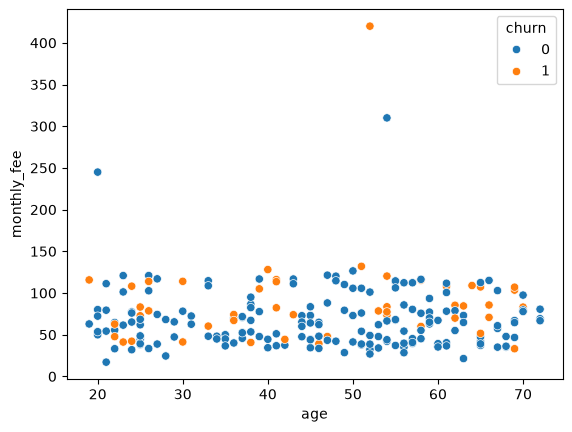

In [9]:
sns.scatterplot(data=df, x='age', y='monthly_fee', hue='churn')
plt.show()
# 정상 범위 내에서 뚜렷한 직선적 관계 보이지 않음
# 이상치는 여기서도 잘 보임 - 점 3개

In [10]:
# 그래프 확인 후 결측치 처리
df['age'] = df['age'].fillna(df['age'].median())
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())
df['city'] = df['city'].fillna(df['city'].mode().iloc[0])

In [11]:
df.isnull().sum()

customer_id      0
age              0
monthly_fee      0
tenure_months    0
support_calls    0
data_usage_gb    0
gender           0
city             0
plan             0
contract_type    0
churn            0
dtype: int64

In [12]:
print(df['gender'].value_counts())
print(df['city'].value_counts())
print(df['plan'].value_counts())
print(df['contract_type'].value_counts())

gender
M    126
F    114
Name: count, dtype: int64
city
Daegu      70
Incheon    65
Seoul      53
Busan      52
Name: count, dtype: int64
plan
Basic       96
Standard    92
Premium     52
Name: count, dtype: int64
contract_type
Month-to-month    128
One-year           77
Two-year           35
Name: count, dtype: int64


In [13]:
# 범주형 처리
df['gender'] = df['gender'].map({
    'M':0,
    'F':1
})

df = pd.get_dummies(df, columns=['city'], dtype=int)
df = pd.get_dummies(df, columns=['plan'], dtype=int)
df = pd.get_dummies(df, columns=['contract_type'], dtype=int)

In [14]:
df.head()

,customer_id,age,monthly_fee,tenure_months,support_calls,data_usage_gb,gender,churn,city_Busan,city_Daegu,city_Incheon,city_Seoul,plan_Basic,plan_Premium,plan_Standard,contract_type_Month-to-month,contract_type_One-year,contract_type_Two-year
0,C0001,59.0,77.1,8,3,23.1,0,0,1,0,0,0,0,0,1,0,1,0
1,C0002,20.0,80.1,6,1,24.1,0,0,1,0,0,0,0,0,1,0,1,0
2,C0003,47.0,47.8,38,1,39.9,0,1,0,0,1,0,1,0,0,1,0,0
3,C0004,25.0,61.9,23,1,29.0,0,0,0,0,1,0,0,0,1,0,0,1
4,C0005,54.0,73.5,19,2,11.0,1,1,1,0,0,0,0,0,1,1,0,0


In [15]:
from sklearn.model_selection import train_test_split

df = df.drop('customer_id', axis=1)

x= df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
from sklearn.preprocessing import StandardScaler

# KNN = 거리 기반이기 때문에 스케일링
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [17]:
# KNN 모델 생성 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train_scaled, y_train)
knn_pred = knn.predict(x_test_scaled)

In [18]:
# 성능 확인
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('accuracy : ' , accuracy_score(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print(classification_report(y_test, knn_pred))


accuracy :  0.7916666666666666
[[37  1]
 [ 9  1]]
              precision    recall  f1-score   support

           0       0.80      0.97      0.88        38
           1       0.50      0.10      0.17        10

    accuracy                           0.79        48
   macro avg       0.65      0.54      0.52        48
weighted avg       0.74      0.79      0.73        48



In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# K 값 조절 - 모든 지표가 좋아지진 않음, 어떤 오류를 줄이고 어떤 오류를 감수할지 균형이 바뀜
knn2 = KNeighborsClassifier(n_neighbors=3)

knn2.fit(x_train_scaled, y_train)
knn_pred2 = knn2.predict(x_test_scaled)

print('accuracy : ' , accuracy_score(y_test, knn_pred2))
print(confusion_matrix(y_test, knn_pred2))
print(classification_report(y_test, knn_pred2))



accuracy :  0.75
[[34  4]
 [ 8  2]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        38
           1       0.33      0.20      0.25        10

    accuracy                           0.75        48
   macro avg       0.57      0.55      0.55        48
weighted avg       0.71      0.75      0.72        48



In [20]:
for k in [1, 3, 5, 7, 9]:
  for_model = KNeighborsClassifier(n_neighbors=k)

  for_model.fit(x_train_scaled, y_train)
  for_pred = for_model.predict(x_test_scaled)

  print(k, accuracy_score(y_test, for_pred))
  print(confusion_matrix(y_test, for_pred))



1 0.625
[[27 11]
 [ 7  3]]
3 0.75
[[34  4]
 [ 8  2]]
5 0.7916666666666666
[[37  1]
 [ 9  1]]
7 0.8125
[[38  0]
 [ 9  1]]
9 0.8125
[[38  0]
 [ 9  1]]


In [21]:
# KNN에 GridSearchCV를 적용해보는 것
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 시험해보고싶은 값
params = {
  'n_neighbors' : [1, 3, 5, 7, 9]
}

grid = GridSearchCV(
  KNeighborsClassifier(),
  params,
  cv=5,
  scoring='recall'
)

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)
# GridSearchCV scoring 기준 best score
print(grid.best_score_)

{'n_neighbors': 1}
0.175


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

params = {
    'n_neighbors':[1, 3, 5, 7, 9]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring='recall'
)

grid.fit(x_train_scaled, y_train)

# K = 1 이 Recall 기준 가장 좋았지만 성능은 낮음
# 후보 중 Recall 기준으로 K=1이 가장 나았지만 Recall 자체가 낮아서 KNN의 성능은 좋지 않다
print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 1}
0.175
